In [1]:
import os
import json
from glob import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import utils

In [5]:
PHENOTYPE_PATH = os.path.join(utils.DATASET_PATH, 'phenotype', 'phenotype_preprocessed.tsv')
HOLDOUTS30_PATH = os.path.join(utils.HOLDOUTS_PATH, '30_holdouts')
SUBJECTS_PATH = os.path.join(utils.DATASET_PATH, 'sub-*')
CONTRAST_NAME = 'incongruent_vs_congruent'
ALT_TEST = 'Incongruent > Congruent'
ALPHA1 = 0.01
ALPHA2 = 0.05
ALPHA3 = 0.1
HEIGHT_CONTROL1 = 'fpr'
HEIGHT_CONTROL2 = 'fdr'
CLUSTER_THRESHOLD1 = 10
CLUSTER_THRESHOLD2 = 20
CLUSTER_THRESHOLD3 = 30
ATLAS1 = 'schaefer'
N_ROIS1 = 1000
YN1 = 17
FEATURE_TABLE_NAME = 'ML_Dataset'
CONSENSUS_THRESHOLDS = [0.7, 0.8, 0.9]

In [6]:
# --- paths for logging and consensus tracking ----------------------------------
LOG_PATH = os.path.join(HOLDOUTS30_PATH, 'iteration_log.jsonl')
ROI_COUNTS_PATH = os.path.join(HOLDOUTS30_PATH, 'roi_occurrence.json')
CONSENSUS_ROIS_PATH = os.path.join(HOLDOUTS30_PATH, 'threshold_wise_consensus_rois.json')

In [4]:
holdouts_info = utils.load_file(HOLDOUTS30_PATH, 'holdouts30_split_ids.json')
phenotype = pd.read_csv(PHENOTYPE_PATH, delimiter='\t')

In [ ]:
# feature_selection_config = {
#         'alpha': ALPHA1,
#         'height_control': HEIGHT_CONTROL1,
#         'two-sided': True,
#         'cluster_threshold':CLUSTER_THRESHOLD2
# }
# TEMP_LOG_PATH = os.path.join(HOLDOUTS30_PATH, 'iteration_log_updated.jsonl')
# with open(LOG_PATH, 'r') as infile, open(TEMP_LOG_PATH, 'w') as outfile:
#     for line in infile:
#         entry = json.loads(line)
        
#         # 2. Check if the key is missing or None
#         if 'feature_selection_config' not in entry:
#             entry['feature_selection_config'] = feature_selection_config
        
#         # 3. Write the (potentially updated) entry back as a JSON line
#         outfile.write(json.dumps(entry) + '\n')
# os.replace(TEMP_LOG_PATH, LOG_PATH)

In [9]:
# --- load existing ROI occurrence counts if resuming ---------------------------
if os.path.exists(ROI_COUNTS_PATH):
    with open (ROI_COUNTS_PATH, 'r') as f:
        roi_occurrence = json.load(f)
else:
    roi_occurrence = {}

# --- load existing log to count valid iterations so far ------------------------
valid_iterations_count = 0
if os.path.exists(LOG_PATH):
    with open(LOG_PATH, 'r') as f:
        for line in f:
            entry = json.loads(line)
            if entry['valid']:
                valid_iterations_count += 1

print(f"Resuming... {valid_iterations_count} valid iterations already completed")
print(f"Alpha: {ALPHA1}, Height control: {HEIGHT_CONTROL1}, Cluster threshold: {CLUSTER_THRESHOLD2}")
print(f"{len(roi_occurrence)} unique ROIs seen so far\n")

# --- batch-wise iterations -----------------------------------------------------
batch = list(holdouts_info.items())[:5]

for key, val in batch:
    holdout_id = key.split('-')[1]
    feature_selection_config = {
        'alpha': ALPHA1,
        'height_control': HEIGHT_CONTROL1,
        'two-sided': True,
        'cluster_threshold':CLUSTER_THRESHOLD2
    }
    print(f"Holdout ID: {holdout_id}")

    # checking if holdout is done
    holdout_processed = False
    if os.path.exists(LOG_PATH):
        with open(LOG_PATH, 'r') as f:
            for line in f:
                entry = json.loads(line)
                if (entry['holdout_id']==holdout_id and 
                   entry['feature_selection_config'] == feature_selection_config):
                    holdout_processed = True
                    break
            if holdout_processed:
                print(f"Holdout {holdout_id} already processed")
                continue
                    
    holdout_i_path = os.path.join(HOLDOUTS30_PATH, key)
    
    # --- ROI identification ----------------------------------------------------
    group_mean_tfmri, group_mean_task_zmap = utils.get_group_mean_maps(
        sub_list=val['slglm'], 
        phenotype_table=phenotype, 
        fl_contrast_name=CONTRAST_NAME, 
        fl_contrast_map_verbose=2,
        sl_verbose=0,
        show_sl_design_matrix=False,
        save_group_mean_tfmri=True, 
        save_group_mean_tfmri_path=holdout_i_path, 
        save_fl_contrasts=True, 
        save_fl_contrasts_path=holdout_i_path, 
        save_sl_design_matrix=True, 
        save_sl_design_matrix_path=holdout_i_path, 
        save_mean_task_zmap=True, 
        save_mean_task_zmap_path=holdout_i_path
    )
    # utils.plot_map(
    #     'roi', group_mean_task_zmap,
    #     f"Group Mean Z-map for {key}", group_mean_tfmri
    # )
    
    group_ROIs_mask, group_ROIs_table, alpha_sub_directory = utils.get_group_task_ROIs(
        group_mean_zmap=group_mean_task_zmap, 
        group_mean_fmri=group_mean_tfmri, 
        alpha=ALPHA1, height_control=HEIGHT_CONTROL1, two_sided=True, 
        cluster_threshold=CLUSTER_THRESHOLD2,
        atlas_name=ATLAS1, n_rois=N_ROIS1, yeo_networks=YN1, 
        save_thresholded_zmap=True, 
        save_thresholded_zmap_path=holdout_i_path, 
        save_ROIs_mask=True, 
        save_ROIs_mask_path=holdout_i_path
    )
    # utils.plot_map(
    #     'roi', group_ROIs_mask,
    #     f"Group ROI Mask for {key}", group_mean_tfmri
    # )

    # check iteration validity
    num_rois = len(group_ROIs_table)
    if num_rois == 0:
        print("[SKIP] No ROIs found\n")
        continue
    print(f"{num_rois} ROIs found")

    # --- update ROI occurrence counts ------------------------------------------
    roi_names = group_ROIs_table['label'].values.tolist()
    for roi in roi_names:
        roi_occurrence[roi] = roi_occurrence.get(roi, 0) + 1

    with open(ROI_COUNTS_PATH, 'w') as f:
        json.dump(roi_occurrence, f, indent=2)

    valid_iterations_count += 1

    # --- feature extraction ----------------------------------------------------
    holdout_i_alpha_j_path = os.path.join(holdout_i_path, alpha_sub_directory)
    
    ml_dataset = utils.create_ml_dataset(
        sub_list=val['ml'], 
        phenotype_table=phenotype, 
        group_ROIs_mask=group_ROIs_mask, 
        group_ROIs_table=group_ROIs_table, 
        fl_contrast_name=CONTRAST_NAME, 
        fl_alt_test=ALT_TEST, 
        save_zmaps=True, save_zmaps_path=holdout_i_path, 
        save_ROIs_zmaps=True, save_ROIs_zmaps_path=holdout_i_alpha_j_path,
        save_ROIs_rest_FC_matrices=True, save_ROIs_rest_FC_matrices_path=holdout_i_alpha_j_path, 
        save_table=True, save_name=f"{FEATURE_TABLE_NAME}_{key}.csv", 
        save_path=holdout_i_alpha_j_path
    )
    print(f"Shape of ML Dataset: {ml_dataset.shape}")
    display(ml_dataset.sample(5))
    print()

    # --- log the iteration ---------------------------------------------------------
    log_entry = {
        'holdout_id': holdout_id,
        'n_rois_found': num_rois,
        'valid': num_rois>0,
        'feature_selection_config': feature_selection_config
    }
    with open(LOG_PATH, 'a') as f:
        f.write(json.dumps(log_entry) + '\n')

# --- consensus ROI plot after each batch ---------------------------------------
if valid_iterations_count > 0:
    ROIs_per_threshold = {t: [] for t in CONSENSUS_THRESHOLDS}
    print("\n --- Consensus ROI counts at current stage ---")
    print(f"Valid iterations count: {valid_iterations_count}")
    print(f"Total unique ROIs seen: {len(roi_occurrence)}\n")

    for threshold in CONSENSUS_THRESHOLDS:
        consensus_rois = [
            roi for roi, count in roi_occurrence.items()
            if count/valid_iterations_count >= threshold
        ]
        print(f"Threshold {int(threshold*100)}%: {len(consensus_rois)} consensus ROIs")
        ROIs_per_threshold[threshold] = consensus_rois

    with open(CONSENSUS_ROIS_PATH, 'w') as f:
        json.dump(ROIs_per_threshold, f, indent=2)

    # bar chart of top ROIs by occurrence
    sorted_rois = sorted(roi_occurrence.items(), key=lambda x: x[1], reverse=True)
    top_n = min(30, len(sorted_rois)) # show top 30 or fewer
    top_names = [r[0] for r in sorted_rois[:top_n]]
    top_counts = [r[1] for r in sorted_rois[:top_n]]
    top_percentages  = [c/valid_iterations_count*100 for c in top_counts]

    fig, ax = plt.subplots(figsize=(14,5))
    bars = ax.barh(top_names, top_percentages, color='steelblue')
    ax.axvline(x=70, color='red', linestyle='--', label='70% threshold')
    ax.axvline(x=80, color='orange', linestyle='--', label='80% threshold')
    ax.axvline(x=90, color='pink', linestyle='--', label='90% threshold')
    ax.set_xlabel('% of valid iterations ROI appeared in')
    ax.set_title(f'ROI Occurrence Across {valid_iterations_count} Valid Iterations')
    ax.legend()
    plt.tight_layout()
    plt.show()

Resuming... 0 valid iterations already completed
Alpha: 0.01, Height control: fpr, Cluster threshold: 20
0 unique ROIs seen so far

Holdout ID: 01
Computed group mean task-fmri
Subjects completed:
24139, 24212, 22956, 23910, 22354, 22268, 24151, 23996, 21214, 24073, 23749, 22353, 23483, 23979, 22477, 23353, 23883, 23494, 24015, 23362, 23261, 24033, 23855, 23972, 23014, 23568, 22487, 23532, 24004, 24021, 24353, 23376, 23971, 23865, 23762, 24240, 22630, 23442, 22871, 22587, 20131, 22818, 23010, 24089, 23631, 24067, 24145, 24038, 24017, 22734, 20725, 23878, 23545, 23407, 24091, 23534, 24236, 22873, 22380, 22475, 
Obtained first-level contrast maps
Created second-level design matrix
Obtained Group mean task maps
Threshold: 2.576
Thresholded the group-task-mean Z-map
Fetched resampled atlas map, labels, and coordinates
Applied atlas on Z-map
Obtained group ROIs mask, labels, and coordinates
135 ROIs found
Subjects completed:
22829, 22831, 22847, 22860, 22862, 22906, 23028, 23044, 23072, 231

,participant_id,LH_VisCent_Striate_1,LH_VisCent_Striate_2,LH_VisCent_ExStr_1,LH_VisCent_ExStr_2,LH_VisCent_ExStr_3,LH_VisCent_ExStr_6,LH_VisCent_ExStr_7,LH_VisCent_ExStr_8,LH_VisCent_ExStr_9,...,RH_DefaultA_IPL_6_to_RH_DefaultA_PFCm_7,RH_DefaultA_IPL_6_to_RH_DefaultA_PFCm_9,RH_DefaultA_IPL_6_to_RH_DefaultC_IPL_2,RH_DefaultA_IPL_6_to_RH_DefaultC_Rsp_1,RH_DefaultA_PFCm_7_to_RH_DefaultA_PFCm_9,RH_DefaultA_PFCm_7_to_RH_DefaultC_IPL_2,RH_DefaultA_PFCm_7_to_RH_DefaultC_Rsp_1,RH_DefaultA_PFCm_9_to_RH_DefaultC_IPL_2,RH_DefaultA_PFCm_9_to_RH_DefaultC_Rsp_1,RH_DefaultC_IPL_2_to_RH_DefaultC_Rsp_1
61,sub-024197,0.28624864181191795,0.18165366479228492,-0.015420770175031287,0.0940968190269299,0.24954651557085306,-0.07858043914806921,0.18480317160186682,0.29713759449452465,0.00911416398852527,...,-0.02323133244970173,-0.06367812170359734,0.23041440740251085,0.014732665271483241,0.0966948226635054,-0.02477776757583543,0.030764427788335914,-0.05100975348311945,0.011335466748552287,0.0651290661852535
16,sub-023381,0.9817936308285944,0.8757437301459506,1.2552717338011115,0.30112369573029607,0.6454250163436562,0.7956636241318733,0.6566774174110165,0.7135649742381636,0.20368371866570262,...,-0.03644298853632774,-0.07026587461799447,0.24606326098423245,-0.09083995836439812,0.14182524088038317,-0.013468043506024973,-0.021380077785495014,0.03501476715361669,-0.0142521607684422,0.011591299175275339
54,sub-024115,0.05974346673822701,0.0,0.20825468341591205,0.11183677864203692,0.24010102279728285,0.1833854243387105,0.01121927991976856,0.23679740303381994,0.0065498503938375965,...,0.0013323029013740505,0.00617335177257928,0.1681837498016433,0.05646270650429849,0.13154882891253206,-0.017630902975658475,0.03168697453790585,-0.004188134019273367,-0.05005013364985036,-0.11220009013918866
51,sub-024046,0.7423436872828847,-0.40437626099083546,-0.8474041009991315,-0.837242512256395,-1.0578266588827905,-0.9190669899365626,-0.16454843081631504,-0.20984443948604628,-0.14814243591803372,...,0.15599545324136146,0.019851363940404022,0.5126951861389474,0.041513599351583455,0.26805635749195345,-0.04151416351827606,0.06903903140911631,-0.029772750483212453,-0.016610518819436444,0.006975793445085377
65,sub-024270,-0.16406277776884853,0.20687291446045694,1.3928614209932393,0.9842797154901195,1.0426557140044865,0.955946613653969,0.6613765310450792,-0.17693052368711634,0.22169019338464183,...,0.058923911484077475,0.1424069486352489,0.16936577904170005,0.014484760023148285,0.11913396229747467,-0.13345985431221627,0.11814443178196052,0.017951664737845662,-0.0487328453240383,-0.005206134041442953



Holdout ID: 02
Computed group mean task-fmri
Subjects completed:
23480, 22630, 23123, 23892, 23392, 22286, 24300, 20725, 24127, 23690, 23353, 22268, 22871, 24142, 24240, 22734, 24276, 23925, 23822, 23376, 24021, 22477, 22829, 22831, 24029, 23946, 22818, 22536, 24270, 23601, 24040, 23381, 23735, 24089, 22281, 23923, 23382, 22532, 23762, 23878, 23971, 23386, 23567, 24212, 24039, 21100, 24260, 22354, 23494, 22600, 22494, 23972, 24022, 23014, 23342, 24017, 22587, 24145, 23072, 23545, 
Obtained first-level contrast maps
Created second-level design matrix
Obtained Group mean task maps
Threshold: 2.576
Thresholded the group-task-mean Z-map
Fetched resampled atlas map, labels, and coordinates
Applied atlas on Z-map
Obtained group ROIs mask, labels, and coordinates
29 ROIs found
Subjects completed:
22847, 22860, 22862, 22873, 22906, 22956, 23010, 23028, 23044, 23257, 23261, 23294, 23303, 23314, 23317, 23362, 23407, 23432, 23442, 23483, 23485, 23501, 23524, 23532, 23534, 23559, 23568, 23572, 23

,participant_id,LH_VisCent_Striate_2,LH_VisCent_Striate_3,LH_VisCent_Striate_4,LH_VisCent_ExStr_13,LH_VisPeri_StriCal_5,LH_VisPeri_StriCal_8,LH_VisPeri_ExStrSup_2,LH_SomMotA_21,LH_SomMotA_32,...,RH_SalVentAttnA_ParMed_2_to_RH_SalVentAttnA_ParMed_3,RH_SalVentAttnA_ParMed_2_to_RH_SalVentAttnA_ParMed_4,RH_SalVentAttnA_ParMed_2_to_RH_SalVentAttnA_ParMed_6,RH_SalVentAttnA_ParMed_2_to_RH_SalVentAttnA_ParMed_7,RH_SalVentAttnA_ParMed_3_to_RH_SalVentAttnA_ParMed_4,RH_SalVentAttnA_ParMed_3_to_RH_SalVentAttnA_ParMed_6,RH_SalVentAttnA_ParMed_3_to_RH_SalVentAttnA_ParMed_7,RH_SalVentAttnA_ParMed_4_to_RH_SalVentAttnA_ParMed_6,RH_SalVentAttnA_ParMed_4_to_RH_SalVentAttnA_ParMed_7,RH_SalVentAttnA_ParMed_6_to_RH_SalVentAttnA_ParMed_7
5,sub-022956,-0.35669761168250647,-1.1910309588635608,0.0,-0.09742724330124007,-0.8035474289305905,-0.3824486490795769,-0.4279284746086056,-0.31066384745439235,-0.5759526251030987,...,0.02436415619219273,0.12784827456702413,-0.0003964340039833465,0.019453255137127298,0.12284392826422555,0.2586658682304121,-0.023219625930318323,0.05771326949439542,0.09350832742554795,0.1434213331592893
59,sub-024139,-0.07040628482254599,-0.09041557258138774,-0.01914924362328473,0.10392813088891861,-0.016097468699270565,-0.02262251828801972,-0.08879507452863927,0.5934748552642526,0.5548421343480411,...,0.10863714345817203,-0.0202325369251221,-0.01740712149727797,0.06994055408072106,0.15780228386118184,0.38469074797650504,-0.0019560557146213946,0.19861007949270038,0.1431018052730199,0.03928398555381875
61,sub-024148,0.14845875905923847,0.2570798679092572,0.024644740757435814,0.00017817646037477877,0.4417681222968168,0.055975318512014594,0.8231060888545486,0.25212413958825003,-0.014487561878686314,...,0.04594697575479054,0.05953513644236388,-0.010266059542299987,0.09064696328898243,0.07200011292215583,0.1751417390642236,0.07910235091891428,0.15250038664060558,0.10600093414380332,0.12059817386724112
56,sub-024106,-0.4561263866722125,-0.9787669527395669,-0.08323905642407545,-0.09664923673919683,-0.8999677367997084,-0.7034596803051093,-0.5578873227260711,-0.7294300302641493,-0.6916575274690868,...,0.15854646479615747,0.16971071757212208,-0.06569332847268862,-0.009567785471580074,0.027651433788944805,0.3027571098990902,0.12176791128852156,0.20742577836963133,0.15661163117476357,-0.20479245137596294
10,sub-023261,1.9881802689406565,1.436665611991723,1.3593241450618054,1.1435894090585343,0.8682875345299252,2.2534171389167192,0.8872850732165525,0.6269057049832857,0.23608528531289755,...,0.07380154777760474,0.1690041813213864,0.053059101796182444,0.030605713013952356,0.012133521471101482,0.17809678667950468,0.06271017841698828,0.3205198061945368,0.10031751396768326,0.06332582074124748



Holdout ID: 03
Computed group mean task-fmri
Subjects completed:
23044, 23342, 23314, 24089, 23559, 24004, 23883, 23735, 22906, 23532, 24240, 24145, 22354, 24115, 24275, 22346, 23925, 22532, 22871, 24091, 20209, 24021, 24353, 23601, 22536, 24276, 22381, 23923, 22686, 23972, 23317, 23392, 23386, 22831, 20131, 23534, 21508, 23257, 23892, 22487, 23572, 24236, 24039, 22380, 22687, 23779, 24146, 23690, 24106, 21100, 24127, 24217, 23987, 23568, 24139, 24151, 23303, 23631, 23842, 24029, 
Obtained first-level contrast maps
Created second-level design matrix
Obtained Group mean task maps
Threshold: 2.576
Thresholded the group-task-mean Z-map
Fetched resampled atlas map, labels, and coordinates
Applied atlas on Z-map
Obtained group ROIs mask, labels, and coordinates
15 ROIs found
Subjects completed:
22734, 22818, 22829, 22847, 22860, 22862, 22873, 22956, 23010, 23014, 23028, 23072, 23123, 23261, 23294, 23353, 23362, 23376, 23381, 23382, 23407, 23432, 23442, 23480, 23483, 23485, 23494, 23501, 23

...


Holdout ID: 04
Computed group mean task-fmri
Subjects completed:
23855, 22494, 23442, 24106, 21100, 23123, 22831, 20725, 23910, 23842, 23622, 22536, 22623, 24146, 23501, 22687, 22381, 24142, 22587, 22600, 23532, 22956, 22366, 22365, 22354, 24197, 24240, 23480, 22727, 23991, 24089, 22172, 24270, 22487, 24073, 24145, 23735, 23629, 24091, 24148, 23985, 23762, 23257, 23572, 23014, 22847, 24198, 23878, 23381, 22686, 24039, 23749, 24017, 22286, 23690, 23883, 24300, 24217, 23567, 23925, 
Obtained first-level contrast maps
Created second-level design matrix
Obtained Group mean task maps
Threshold: 2.576
Thresholded the group-task-mean Z-map
Fetched resampled atlas map, labels, and coordinates
Applied atlas on Z-map
Obtained group ROIs mask, labels, and coordinates
77 ROIs found
Subjects completed:
22734, 22818, 22829, 22860, 22862, 22871, 22873, 22906, 23010, 23028, 23044, 23072, 23261, 23294, 23303, 23314, 23317, 23342, 23353, 23362, 23376, 23382, 23386, 23392, 23407, 23432, 23483, 23485, 23

,participant_id,LH_SalVentAttnA_FrMed_7,LH_SalVentAttnB_Ins_1,LH_SalVentAttnB_Ins_2,LH_SalVentAttnB_Ins_3,LH_SalVentAttnB_Ins_4,LH_SalVentAttnB_Ins_5,LH_SalVentAttnB_PFCmp_1,LH_DefaultA_PFCd_3,LH_DefaultA_PFCm_11,...,RH_DefaultB_Temp_2_to_RH_DefaultB_AntTemp_3,RH_DefaultB_Temp_2_to_RH_DefaultB_PFCd_6,RH_DefaultB_Temp_2_to_RH_DefaultB_PFCd_8,RH_DefaultB_Temp_2_to_RH_TempPar_4,RH_DefaultB_AntTemp_3_to_RH_DefaultB_PFCd_6,RH_DefaultB_AntTemp_3_to_RH_DefaultB_PFCd_8,RH_DefaultB_AntTemp_3_to_RH_TempPar_4,RH_DefaultB_PFCd_6_to_RH_DefaultB_PFCd_8,RH_DefaultB_PFCd_6_to_RH_TempPar_4,RH_DefaultB_PFCd_8_to_RH_TempPar_4
70,sub-024260,0.15409820546819153,-0.067688698295971,-0.03972379740797674,0.013672966375632579,0.1972281449727203,0.3277706739964966,0.23039316599791113,0.10421669001972901,-0.23538966139908693,...,0.21517325679707147,0.039748086913753373,0.145998908744338,0.45088253664433076,0.12826055551211574,-0.05069556777238145,-0.1651603741202239,0.2278166884990727,0.08243061214989823,-0.018455521499927525
5,sub-022871,1.1158498982784362,1.174648755684265,1.5354223928217865,1.9338756182947339,1.5215293082290564,1.5297753947099035,0.7320189189720964,0.4511285090226676,0.8116275107088672,...,0.04997333634747252,0.12660599800910344,0.06160591590680024,0.23982443764545397,0.06051769411319552,-0.03809528690772447,0.12256803819552607,0.2683581819089993,-0.01488818933066693,0.03387642544456187
77,sub-021508,-0.02670613637966042,-0.17269529995184676,-0.04301298350492541,-0.11269619912251472,-0.545772271836006,-0.16793030342343754,-0.27462068109099447,0.007021921881234149,-0.04138822987919897,...,-0.14781911585295082,-0.0006534511856145642,-0.032081886333885666,0.17912326971302503,0.1086387091609981,-0.060681139579736205,-0.05340013274779802,0.02805203404016016,-0.06155538122647228,0.025863188353990443
84,sub-022475,0.33512396502810754,0.18111291402566057,0.12974026627481197,0.3385133235270922,0.562759514510536,0.40442982806268946,0.4208909117397838,0.3670232991352261,0.6531123373891942,...,-0.04715861568626093,0.036249914129674855,-0.008827918334452735,0.16933265490684324,-0.08456464906423274,0.05075046838714857,0.017853978630479602,0.08506737506876007,-0.10334796921740683,-0.026706350744959105
74,sub-020131,0.3557276098747945,0.19274938287662777,-0.12847687695010526,-0.3439084919610794,-0.11850619997960755,0.07156481001071162,0.1319278884798682,-0.23254816029519984,0.43187261587419445,...,-0.06188793739741772,-0.067918593091432,0.08188933933743031,0.056926240447012944,-0.04232829837639071,-0.019281964771566358,-0.06958422524600007,0.17840687898702684,0.016829768211167644,0.11000619923807427



Holdout ID: 05
Computed group mean task-fmri
Subjects completed:
23855, 23996, 23376, 24146, 21214, 23524, 23342, 23257, 22860, 24148, 23986, 23072, 23762, 22380, 24089, 23971, 23567, 23381, 23923, 23735, 22862, 23910, 22494, 23480, 23353, 23314, 22600, 23494, 24017, 24260, 24091, 24236, 24217, 24270, 23584, 23010, 24353, 22687, 23559, 24038, 23622, 23883, 23407, 23317, 24198, 22727, 23483, 24275, 22475, 23501, 22734, 21100, 23985, 24067, 22623, 23892, 22268, 23664, 22353, 23991, 
Obtained first-level contrast maps
Created second-level design matrix
Obtained Group mean task maps
Threshold: 2.576
Thresholded the group-task-mean Z-map
Fetched resampled atlas map, labels, and coordinates
Applied atlas on Z-map
Obtained group ROIs mask, labels, and coordinates
9 ROIs found
Subjects completed:
22818, 22829, 22831, 22847, 22871, 22873, 22906, 22956, 23014, 23028, 23044, 23123, 23261, 23294, 23303, 23362, 23382, 23386, 23392, 23432, 23442, 23485, 23532, 23534, 23545, 23568, 23572, 23601, 236

,participant_id,LH_SalVentAttnB_OFC_1,LH_LimbicB_OFC_13,LH_LimbicB_OFC_15,LH_LimbicB_OFC_16,LH_ContB_PFClv_1,LH_ContB_PFClv_2,LH_DefaultA_PFCm_1,LH_DefaultA_PFCm_5,LH_DefaultB_PFCv_5,...,LH_ContB_PFClv_1_to_LH_ContB_PFClv_2,LH_ContB_PFClv_1_to_LH_DefaultA_PFCm_1,LH_ContB_PFClv_1_to_LH_DefaultA_PFCm_5,LH_ContB_PFClv_1_to_LH_DefaultB_PFCv_5,LH_ContB_PFClv_2_to_LH_DefaultA_PFCm_1,LH_ContB_PFClv_2_to_LH_DefaultA_PFCm_5,LH_ContB_PFClv_2_to_LH_DefaultB_PFCv_5,LH_DefaultA_PFCm_1_to_LH_DefaultA_PFCm_5,LH_DefaultA_PFCm_1_to_LH_DefaultB_PFCv_5,LH_DefaultA_PFCm_5_to_LH_DefaultB_PFCv_5
18,sub-023392,0.004184647112109529,-0.1407475587623359,-0.07557905552884278,-0.8328689450227563,0.026465954795526,-0.20297644912642412,-0.3876016012265901,-1.1766498473741622,-0.35527716379263924,...,0.12840986868940968,-0.15115730331656885,0.1220745974650447,0.026891319910522026,0.4361714756864895,0.13540770853113684,0.6542772123158654,0.7576678111080641,0.06492228664287657,-0.19375972971132738
40,sub-023972,0.3657030197371796,0.36575795816707224,0.27434052091328326,0.3914495200255873,0.12280076229517159,0.7844377480328543,0.6398553392643316,0.668017540783278,0.5454785055616579,...,0.3529262982257491,0.28758457766337936,-0.07411767205219826,0.2159857267974416,-0.29939324413033586,0.3998925785173031,0.5299802840530788,0.681111677420094,0.3287296804335187,-0.21440322727902586
57,sub-024127,-0.4425059201423711,-0.21014273812203885,-0.25466937978390974,-0.38903368417609524,-0.11078995593969856,-0.4865585304633299,-0.3601258159540939,-0.26170900839935746,-0.2189154692597017,...,0.1623263027377248,-0.2758925620642858,-0.02060197205020928,0.04156606675312551,-0.3745320030600886,0.011073329682424582,1.00397823313691,0.5251467169932741,0.5765182110082786,-0.045293806071738156
5,sub-022873,-0.4090147071381256,0.02631130910825994,-0.2869787922382423,0.35131400702279314,0.029176447818957913,0.09406961015538631,0.17952029713553322,0.596895120804613,0.07457992661907525,...,0.4486717198738663,0.24870839670768205,-0.08139189647565048,0.031980266466351576,-0.0398528606518673,0.4154923053860303,0.5933116913446808,0.4724095825040799,-0.008932983272359694,0.11110650747315295
56,sub-024118,-0.13203785101479534,-0.26234360702551074,-0.0008536723033551623,-0.7004758669058031,0.09762768742761867,0.2733434042458832,0.04773814587131445,-0.6756088674283472,-0.19485101068944158,...,0.3947983558765058,-0.38517090588091735,0.10368094832225506,-0.13230710427160727,0.2387992785537336,0.1584463874815415,0.7470338602040106,0.6868243222060584,0.04642977307252505,-0.0930506305923683


NameError: name 'consensus_thresholds' is not defined

Resuming... 5 valid iterations already completed
Alpha: 0.01, Height control: fpr, Cluster threshold: 20
254 unique ROIs seen so far

Holdout ID: 01
Holdout 01 already processed
Holdout ID: 02
Holdout 02 already processed
Holdout ID: 03
Holdout 03 already processed
Holdout ID: 04
Holdout 04 already processed
Holdout ID: 05
Holdout 05 already processed

 --- Consensus ROI counts at current stage ---
Valid iterations count: 5
Total unique ROIs seen: 254

Threshold 70%: 0 consensus ROIs
Threshold 80%: 0 consensus ROIs
Threshold 90%: 0 consensus ROIs


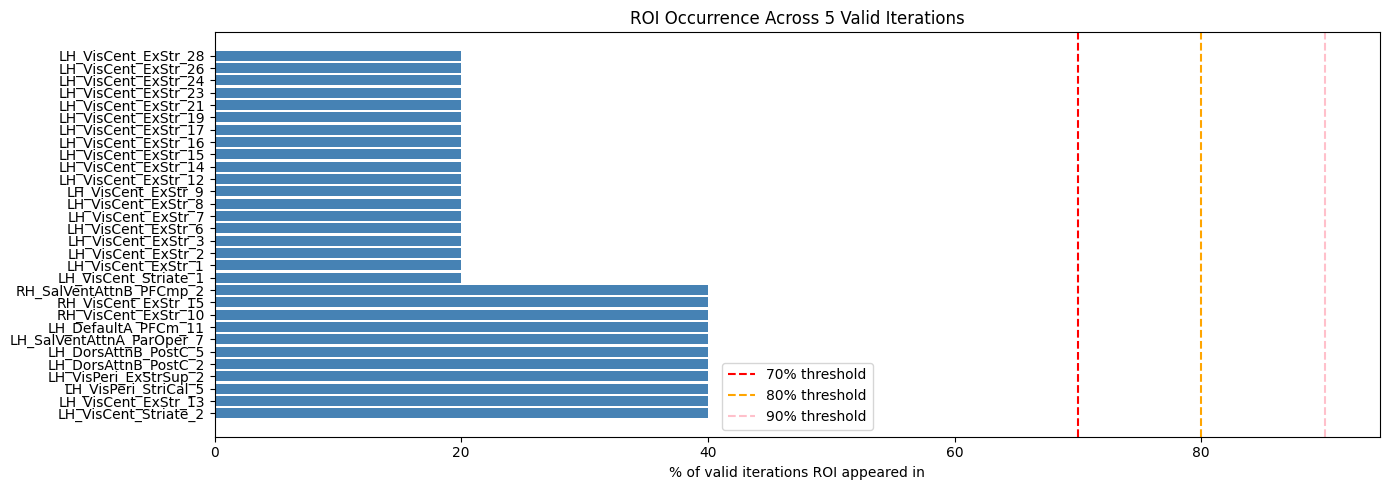

In [13]:
# --- load existing ROI occurrence counts if resuming ---------------------------
if os.path.exists(ROI_COUNTS_PATH):
    with open (ROI_COUNTS_PATH, 'r') as f:
        roi_occurrence = json.load(f)
else:
    roi_occurrence = {}

# --- load existing log to count valid iterations so far ------------------------
valid_iterations_count = 0
if os.path.exists(LOG_PATH):
    with open(LOG_PATH, 'r') as f:
        for line in f:
            entry = json.loads(line)
            if entry['valid']:
                valid_iterations_count += 1

print(f"Resuming... {valid_iterations_count} valid iterations already completed")
print(f"Alpha: {ALPHA1}, Height control: {HEIGHT_CONTROL1}, Cluster threshold: {CLUSTER_THRESHOLD2}")
print(f"{len(roi_occurrence)} unique ROIs seen so far\n")

# --- batch-wise iterations -----------------------------------------------------
batch = list(holdouts_info.items())[:5]

for key, val in batch:
    holdout_id = key.split('-')[1]
    feature_selection_config = {
        'alpha': ALPHA1,
        'height_control': HEIGHT_CONTROL1,
        'two-sided': True,
        'cluster_threshold':CLUSTER_THRESHOLD2
    }
    print(f"Holdout ID: {holdout_id}")

    # checking if holdout is done
    holdout_processed = False
    if os.path.exists(LOG_PATH):
        with open(LOG_PATH, 'r') as f:
            for line in f:
                entry = json.loads(line)
                if (entry['holdout_id']==holdout_id and 
                   entry['feature_selection_config'] == feature_selection_config):
                    holdout_processed = True
                    break
            if holdout_processed:
                print(f"Holdout {holdout_id} already processed")
                continue
                    
    holdout_i_path = os.path.join(HOLDOUTS30_PATH, key)
    
    # --- ROI identification ----------------------------------------------------
    group_mean_tfmri, group_mean_task_zmap = utils.get_group_mean_maps(
        sub_list=val['slglm'], 
        phenotype_table=phenotype, 
        fl_contrast_name=CONTRAST_NAME, 
        fl_contrast_map_verbose=2,
        sl_verbose=0,
        show_sl_design_matrix=False,
        save_group_mean_tfmri=True, 
        save_group_mean_tfmri_path=holdout_i_path, 
        save_fl_contrasts=True, 
        save_fl_contrasts_path=holdout_i_path, 
        save_sl_design_matrix=True, 
        save_sl_design_matrix_path=holdout_i_path, 
        save_mean_task_zmap=True, 
        save_mean_task_zmap_path=holdout_i_path
    )
    # utils.plot_map(
    #     'roi', group_mean_task_zmap,
    #     f"Group Mean Z-map for {key}", group_mean_tfmri
    # )
    
    group_ROIs_mask, group_ROIs_table, alpha_sub_directory = utils.get_group_task_ROIs(
        group_mean_zmap=group_mean_task_zmap, 
        group_mean_fmri=group_mean_tfmri, 
        alpha=ALPHA1, height_control=HEIGHT_CONTROL1, two_sided=True, 
        cluster_threshold=CLUSTER_THRESHOLD2,
        atlas_name=ATLAS1, n_rois=N_ROIS1, yeo_networks=YN1, 
        save_thresholded_zmap=True, 
        save_thresholded_zmap_path=holdout_i_path, 
        save_ROIs_mask=True, 
        save_ROIs_mask_path=holdout_i_path
    )
    # utils.plot_map(
    #     'roi', group_ROIs_mask,
    #     f"Group ROI Mask for {key}", group_mean_tfmri
    # )

    # check iteration validity
    num_rois = len(group_ROIs_table)
    if num_rois == 0:
        print("[SKIP] No ROIs found\n")
        continue
    print(f"{num_rois} ROIs found")

    # --- update ROI occurrence counts ------------------------------------------
    roi_names = group_ROIs_table['label'].values.tolist()
    for roi in roi_names:
        roi_occurrence[roi] = roi_occurrence.get(roi, 0) + 1

    with open(ROI_COUNTS_PATH, 'w') as f:
        json.dump(roi_occurrence, f, indent=2)

    valid_iterations_count += 1

    # --- feature extraction ----------------------------------------------------
    holdout_i_alpha_j_path = os.path.join(holdout_i_path, alpha_sub_directory)
    
    ml_dataset = utils.create_ml_dataset(
        sub_list=val['ml'], 
        phenotype_table=phenotype, 
        group_ROIs_mask=group_ROIs_mask, 
        group_ROIs_table=group_ROIs_table, 
        fl_contrast_name=CONTRAST_NAME, 
        fl_alt_test=ALT_TEST, 
        save_zmaps=True, save_zmaps_path=holdout_i_path, 
        save_ROIs_zmaps=True, save_ROIs_zmaps_path=holdout_i_alpha_j_path,
        save_ROIs_rest_FC_matrices=True, save_ROIs_rest_FC_matrices_path=holdout_i_alpha_j_path, 
        save_table=True, save_name=f"{FEATURE_TABLE_NAME}_{key}.csv", 
        save_path=holdout_i_alpha_j_path
    )
    print(f"Shape of ML Dataset: {ml_dataset.shape}")
    display(ml_dataset.sample(5))
    print()

    # --- log the iteration ---------------------------------------------------------
    log_entry = {
        'holdout_id': holdout_id,
        'n_rois_found': num_rois,
        'valid': num_rois>0,
        'feature_selection_config': feature_selection_config
    }
    with open(LOG_PATH, 'a') as f:
        f.write(json.dumps(log_entry) + '\n')

# --- consensus ROI plot after each batch ---------------------------------------
if valid_iterations_count > 0:
    ROIs_per_threshold = {t: [] for t in CONSENSUS_THRESHOLDS}
    print("\n --- Consensus ROI counts at current stage ---")
    print(f"Valid iterations count: {valid_iterations_count}")
    print(f"Total unique ROIs seen: {len(roi_occurrence)}\n")

    for threshold in CONSENSUS_THRESHOLDS:
        consensus_rois = [
            roi for roi, count in roi_occurrence.items()
            if count/valid_iterations_count >= threshold
        ]
        print(f"Threshold {int(threshold*100)}%: {len(consensus_rois)} consensus ROIs")
        ROIs_per_threshold[threshold] = consensus_rois

    with open(CONSENSUS_ROIS_PATH, 'w') as f:
        json.dump(ROIs_per_threshold, f, indent=2)

    # bar chart of top ROIs by occurrence
    sorted_rois = sorted(roi_occurrence.items(), key=lambda x: x[1], reverse=True)
    top_n = min(30, len(sorted_rois)) # show top 30 or fewer
    top_names = [r[0] for r in sorted_rois[:top_n]]
    top_counts = [r[1] for r in sorted_rois[:top_n]]
    top_percentages  = [c/valid_iterations_count*100 for c in top_counts]

    fig, ax = plt.subplots(figsize=(14,5))
    bars = ax.barh(top_names, top_percentages, color='steelblue')
    ax.axvline(x=70, color='red', linestyle='--', label='70% threshold')
    ax.axvline(x=80, color='orange', linestyle='--', label='80% threshold')
    ax.axvline(x=90, color='pink', linestyle='--', label='90% threshold')
    ax.set_xlabel('% of valid iterations ROI appeared in')
    ax.set_title(f'ROI Occurrence Across {valid_iterations_count} Valid Iterations')
    ax.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
# --- load existing ROI occurrence counts if resuming ---------------------------
if os.path.exists(ROI_COUNTS_PATH):
    with open (ROI_COUNTS_PATH, 'r') as f:
        roi_occurrence = json.load(f)
else:
    roi_occurrence = {}

# --- load existing log to count valid iterations so far ------------------------
valid_iterations_count = 0
if os.path.exists(LOG_PATH):
    with open(LOG_PATH, 'r') as f:
        for line in f:
            entry = json.loads(line)
            if entry['valid']:
                valid_iterations_count += 1

print(f"Resuming... {valid_iterations_count} valid iterations already completed")
print(f"Alpha: {ALPHA1}, Height control: {HEIGHT_CONTROL1}, Cluster threshold: {CLUSTER_THRESHOLD2}")
print(f"{len(roi_occurrence)} unique ROIs seen so far\n")

# --- batch-wise iterations -----------------------------------------------------
batch = list(holdouts_info.items())[5:10]

for key, val in batch:
    holdout_id = key.split('-')[1]
    feature_selection_config = {
        'alpha': ALPHA1,
        'height_control': HEIGHT_CONTROL1,
        'two-sided': True,
        'cluster_threshold':CLUSTER_THRESHOLD2
    }
    print(f"Holdout ID: {holdout_id}")

    # checking if holdout is done
    holdout_processed = False
    if os.path.exists(LOG_PATH):
        with open(LOG_PATH, 'r') as f:
            for line in f:
                entry = json.loads(line)
                if (entry['holdout_id']==holdout_id and 
                   entry['feature_selection_config'] == feature_selection_config):
                    holdout_processed = True
                    break
            if holdout_processed:
                print(f"Holdout {holdout_id} already processed")
                continue
                    
    holdout_i_path = os.path.join(HOLDOUTS30_PATH, key)
    
    # --- ROI identification ----------------------------------------------------
    group_mean_tfmri, group_mean_task_zmap = utils.get_group_mean_maps(
        sub_list=val['slglm'], 
        phenotype_table=phenotype, 
        fl_contrast_name=CONTRAST_NAME, 
        fl_contrast_map_verbose=2,
        sl_verbose=0,
        show_sl_design_matrix=False,
        save_group_mean_tfmri=True, 
        save_group_mean_tfmri_path=holdout_i_path, 
        save_fl_contrasts=True, 
        save_fl_contrasts_path=holdout_i_path, 
        save_sl_design_matrix=True, 
        save_sl_design_matrix_path=holdout_i_path, 
        save_mean_task_zmap=True, 
        save_mean_task_zmap_path=holdout_i_path
    )
    # utils.plot_map(
    #     'roi', group_mean_task_zmap,
    #     f"Group Mean Z-map for {key}", group_mean_tfmri
    # )
    
    group_ROIs_mask, group_ROIs_table, alpha_sub_directory = utils.get_group_task_ROIs(
        group_mean_zmap=group_mean_task_zmap, 
        group_mean_fmri=group_mean_tfmri, 
        alpha=ALPHA1, height_control=HEIGHT_CONTROL1, two_sided=True, 
        cluster_threshold=CLUSTER_THRESHOLD2,
        atlas_name=ATLAS1, n_rois=N_ROIS1, yeo_networks=YN1, 
        save_thresholded_zmap=True, 
        save_thresholded_zmap_path=holdout_i_path, 
        save_ROIs_mask=True, 
        save_ROIs_mask_path=holdout_i_path
    )
    # utils.plot_map(
    #     'roi', group_ROIs_mask,
    #     f"Group ROI Mask for {key}", group_mean_tfmri
    # )

    # check iteration validity
    num_rois = len(group_ROIs_table)
    if num_rois == 0:
        print("[SKIP] No ROIs found\n")
        continue
    print(f"{num_rois} ROIs found")

    # --- update ROI occurrence counts ------------------------------------------
    roi_names = group_ROIs_table['label'].values.tolist()
    for roi in roi_names:
        roi_occurrence[roi] = roi_occurrence.get(roi, 0) + 1

    with open(ROI_COUNTS_PATH, 'w') as f:
        json.dump(roi_occurrence, f, indent=2)

    valid_iterations_count += 1

    # --- feature extraction ----------------------------------------------------
    holdout_i_alpha_j_path = os.path.join(holdout_i_path, alpha_sub_directory)
    
    ml_dataset = utils.create_ml_dataset(
        sub_list=val['ml'], 
        phenotype_table=phenotype, 
        group_ROIs_mask=group_ROIs_mask, 
        group_ROIs_table=group_ROIs_table, 
        fl_contrast_name=CONTRAST_NAME, 
        fl_alt_test=ALT_TEST, 
        save_zmaps=True, save_zmaps_path=holdout_i_path, 
        save_ROIs_zmaps=True, save_ROIs_zmaps_path=holdout_i_alpha_j_path,
        save_ROIs_rest_FC_matrices=True, save_ROIs_rest_FC_matrices_path=holdout_i_alpha_j_path, 
        save_table=True, save_name=f"{FEATURE_TABLE_NAME}_{key}.csv", 
        save_path=holdout_i_alpha_j_path
    )
    print(f"Shape of ML Dataset: {ml_dataset.shape}")
    display(ml_dataset.sample(5))
    print()

    # --- log the iteration ---------------------------------------------------------
    log_entry = {
        'holdout_id': holdout_id,
        'n_rois_found': num_rois,
        'valid': num_rois>0,
        'feature_selection_config': feature_selection_config
    }
    with open(LOG_PATH, 'a') as f:
        f.write(json.dumps(log_entry) + '\n')

# --- consensus ROI plot after each batch ---------------------------------------
if valid_iterations_count > 0:
    ROIs_per_threshold = {t: [] for t in CONSENSUS_THRESHOLDS}
    print("\n --- Consensus ROI counts at current stage ---")
    print(f"Valid iterations count: {valid_iterations_count}")
    print(f"Total unique ROIs seen: {len(roi_occurrence)}\n")

    for threshold in CONSENSUS_THRESHOLDS:
        consensus_rois = [
            roi for roi, count in roi_occurrence.items()
            if count/valid_iterations_count >= threshold
        ]
        print(f"Threshold {int(threshold*100)}%: {len(consensus_rois)} consensus ROIs")
        ROIs_per_threshold[threshold] = consensus_rois

    with open(CONSENSUS_ROIS_PATH, 'w') as f:
        json.dump(ROIs_per_threshold, f, indent=2)

    # bar chart of top ROIs by occurrence
    sorted_rois = sorted(roi_occurrence.items(), key=lambda x: x[1], reverse=True)
    top_n = min(30, len(sorted_rois)) # show top 30 or fewer
    top_names = [r[0] for r in sorted_rois[:top_n]]
    top_counts = [r[1] for r in sorted_rois[:top_n]]
    top_percentages  = [c/valid_iterations_count*100 for c in top_counts]

    fig, ax = plt.subplots(figsize=(14,5))
    bars = ax.barh(top_names, top_percentages, color='steelblue')
    ax.axvline(x=70, color='red', linestyle='--', label='70% threshold')
    ax.axvline(x=80, color='orange', linestyle='--', label='80% threshold')
    ax.axvline(x=90, color='pink', linestyle='--', label='90% threshold')
    ax.set_xlabel('% of valid iterations ROI appeared in')
    ax.set_title(f'ROI Occurrence Across {valid_iterations_count} Valid Iterations')
    ax.legend()
    plt.tight_layout()
    plt.show()